## 1.1 Problem Formulation, Data Acquisition and Preparation

### Loading the Libraries and Packages

In [1]:
## Loading libraries and Packages
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

### Loading the Data

In [2]:
# Loading the data
BNPL_Data = pd.read_csv("Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")

### Data Cleaning and Data Screening

In [3]:
# Data Screening
BNPL_Data.head(30)

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk
5,6,52,Self-Employed,79950.32,729,5000.00,Fashion,9,1,0,0,6.32,Canada,2024-08-29,0.062539,50.4,Low Risk
6,7,44,Salaried,43192.27,511,5000.00,Sports,3,2,0,0,5.58,USA,2024-08-21,0.115761,139.6,High Risk
7,8,54,Unemployed,9434.80,369,1686.24,Fashion,3,0,0,1,3.66,Germany,2024-11-17,0.178726,192.4,High Risk
8,9,45,Student,14821.44,306,3628.68,Electronics,9,20,2,1,2.48,USA,2024-11-14,0.244826,297.6,High Risk
9,10,54,Unemployed,6737.92,318,100.00,Home,6,4,0,0,9.66,UK,2023-06-09,0.014841,220.8,High Risk


### Checking for Missing values

In [4]:
# Check the data types of each of the columns and see if there is any missing values in the columns
BNPL_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score         

In [5]:
# Check if there is any missing values in any of the rows
BNPL_Data[BNPL_Data.isnull().any(axis =1)]

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment


### Make sure values falls within proper value ranges

In [6]:
# Check if the values in each column are within range specified in the Data Dictionary
# For Quantitative Columns
BNPL_Data.describe()

# Checking if there are any typo or additional values out of the data dictionary
# BNPL_Data["employment_type"].unique()
# BNPL_Data["product_category"].unique()
# BNPL_Data["location"].unique()
# BNPL_Data["customer_segment"].unique()
# BNPL_Data["transaction_date"].unique()

,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000
mean,5173.000000,38.559884,35053.381898,448.176124,3979.402721,7.477525,8.742774,1.015950,0.390527,5.524101,0.181071,198.534094
std,2986.488601,12.131789,27084.517277,136.518332,1500.828483,3.362867,6.781849,0.996726,0.487892,2.590364,0.124887,67.541384
min,1.000000,18.000000,5000.000000,300.000000,100.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000
25%,2587.000000,28.000000,12207.020000,332.000000,2990.720000,3.000000,2.000000,0.000000,0.000000,3.300000,0.080187,153.600000
50%,5173.000000,39.000000,23800.520000,403.000000,5000.000000,9.000000,9.000000,1.000000,0.000000,5.550000,0.138263,202.800000
75%,7759.000000,49.000000,55276.930000,547.000000,5000.000000,9.000000,14.000000,2.000000,1.000000,7.750000,0.268300,250.800000
max,10345.000000,59.000000,145767.120000,850.000000,5000.000000,12.000000,33.000000,7.000000,1.000000,10.000000,0.723460,398.000000


### Checking for duplicated values

In [43]:
# Checking for sum of duplicated values, returning 0 means there is no duplicated rows
BNPL_Data.duplicated().sum()

0

## 1.2 Exploration

In [7]:
# Checking the proportion of different categories This is for EDA
# Insight: The proportion of the categories in each variable stated below are all quite even (well balanced)
BNPL_Data['location'].value_counts(normalize = True)
BNPL_Data['employment_type'].value_counts(normalize = True)
BNPL_Data['product_category'].value_counts(normalize = True)
BNPL_Data['age'].value_counts(normalize = True)

26    0.026486
51    0.025906
53    0.025713
35    0.025713
20    0.025616
55    0.025326
21    0.025230
45    0.025133
28    0.025133
24    0.025036
40    0.025036
57    0.024843
50    0.024650
43    0.024360
54    0.024263
59    0.024263
31    0.024263
46    0.024166
39    0.024166
49    0.023973
33    0.023973
27    0.023876
52    0.023876
32    0.023586
19    0.023586
44    0.023490
42    0.023490
22    0.023393
48    0.023103
30    0.023006
36    0.022813
37    0.022620
29    0.022523
38    0.022330
47    0.022330
25    0.022330
58    0.021943
56    0.021943
34    0.021750
41    0.021750
23    0.021556
18    0.021460
Name: age, dtype: float64

## Data Validation and Sanity Checks

**The current average mean monthly income is 35000 USD based on the data, which looks quite unrealistic, its more like an annual income figure. Therefore, I will be dividing the current monthly_income by 12 which will also affect the debt to income ratio.**

**Since it is not mentioned in the Data Dictionary, I will assume that it follows a monthly repayment plan. A monthly_installment variable is created have a better picture of how much each user needs to pay per month and an updated debt to income ratio is made to reflect more accurate monthly debt to income ratio value.** 

In [8]:
# Divide the current monthly income value by 12 (to make it truely monthly=)
BNPL_Data['monthly_income'] = BNPL_Data['monthly_income']/12

# Create a new variable called monthly_installment (Feature Engineering)
BNPL_Data['monthly_installment'] = BNPL_Data['purchase_amount']/BNPL_Data['bnpl_installments']

# Updated the debt to income ratio with monthly figures
BNPL_Data['debt_to_income_ratio'] = BNPL_Data['monthly_installment']/BNPL_Data['monthly_income']

In [9]:
BNPL_Data.head(30)

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment,monthly_installment
0,1,56,Salaried,5710.791667,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk,416.666667
1,2,19,Student,603.987500,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk,89.435833
2,3,20,Self-Employed,3465.188333,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.480974,229.6,High Risk,1666.666667
3,4,21,Salaried,1201.955000,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.565305,356.0,High Risk,679.471667
4,5,43,Salaried,3570.458333,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.155598,135.2,High Risk,555.555556
5,6,52,Self-Employed,6662.526667,729,5000.00,Fashion,9,1,0,0,6.32,Canada,2024-08-29,0.083385,50.4,Low Risk,555.555556
6,7,44,Salaried,3599.355833,511,5000.00,Sports,3,2,0,0,5.58,USA,2024-08-21,0.463046,139.6,High Risk,1666.666667
7,8,54,Unemployed,786.233333,369,1686.24,Fashion,3,0,0,1,3.66,Germany,2024-11-17,0.714902,192.4,High Risk,562.080000
8,9,45,Student,1235.120000,306,3628.68,Electronics,9,20,2,1,2.48,USA,2024-11-14,0.326435,297.6,High Risk,403.186667
9,10,54,Unemployed,561.493333,318,100.00,Home,6,4,0,0,9.66,UK,2023-06-09,0.029683,220.8,High Risk,16.666667


## Question 1: What Customers are mostly likely to default in BNPL services?

**For this question, I decide to look into 3 areas (Demographic, Financial health and Repayment Behaviours), From the 3 area of analysis, I am able to see that Customers that are most likely to default are the ones that do not have a stable source of income or have a a median income less than 2000 dollars per month. Moreover, customers are more likely to default with a higher debt to income ratio as there is more finanical burden as the debt cover a higher proportion of the income and lastly if a customer have increasing number of missed payments then it is a strong sign that they are not financially capable to pay off the repayments.**

**That being said, the current dataset only does not represent a full picture of the a person. As therer other financial factors (other form of debt) and non financial factors like spending behaviour that influences a persons ability to repay BNPL payments. The below figures and analysis shows a more detailed description of each of the area of analysis.**

In [10]:
# The proportion of Customers that defaults and not default
# Insight: The default rate in the dataset is 39%
BNPL_Data['default_flag'].value_counts(normalize = True)

0    0.609473
1    0.390527
Name: default_flag, dtype: float64

In [11]:
# Demographic Analysis 

# Average age of customers that defaults
# Insight: The average age of customers that default is 37.41 years old
BNPL_Data.groupby('default_flag')['age'].mean()

default_flag
0    39.295004
1    37.412624
Name: age, dtype: float64

## Demographic Analysis

### 1a Visualizing the Default Rates across different age groups for each of the employment type

In [12]:
# Creating the age bins for the customer using feature engineering 
bins = [18, 25, 35, 45, 55, 60]
labels = ['18-24','25-34','35-44','45-54','55-59']

# Adding a new column into the dataset called age_group
BNPL_Data['age_group'] = pd.cut(BNPL_Data['age'], bins=bins, labels=labels, right=False)

# Calculating the default rates
default_rates = (BNPL_Data.groupby(['employment_type','age_group'])['default_flag'].mean().reset_index())

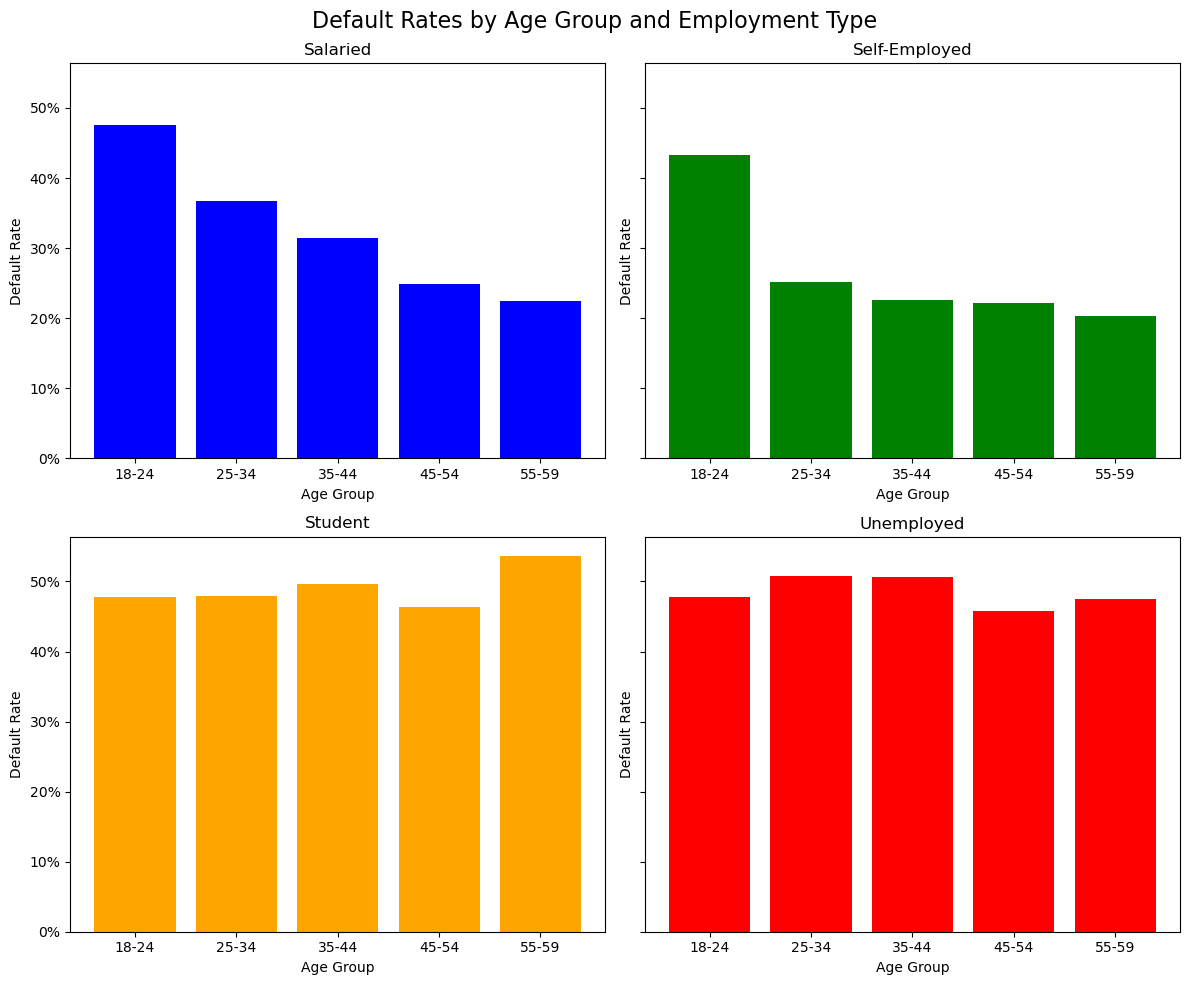

In [13]:
from matplotlib.ticker import PercentFormatter

employment_types = default_rates['employment_type'].unique()

# Colour coding each of the employment type
color_map = {
    'Salaried': 'blue',
    'Student': 'orange',
    'Self-Employed': 'green',
    'Unemployed': 'red'}

#Setting up for bar charts in a 2 by 2 space
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    sharey=True)

axes = axes.flatten()

# specifications for each of the bar charts per employment type 
for i, emp in enumerate(employment_types):

    subset = default_rates[default_rates['employment_type'] == emp]

    axes[i].bar(
        subset['age_group'].astype(str),
        subset['default_flag'],
        color=color_map.get(emp))

    axes[i].set_title(emp)
    axes[i].set_xlabel('Age Group')
    axes[i].set_ylabel('Default Rate')

    # Convert y-axis to percentage
    axes[i].yaxis.set_major_formatter(
        PercentFormatter(1))
    
    fig.suptitle('Default Rates by Age Group and Employment Type',fontsize=16)

plt.tight_layout()

plt.show()

**Based on the above bar charts we are able to see that overall, the students and unemployed group of people tends to have higher default rates which is rational as they may not have a stable income source, Which is proven by the the selef-employed and employed group of people where there is a lower default rate overall. However, its interesting to note that the default rate is quite similar accross all age group for the student and unemployed group where as there is a decline in default rates in the employed and self-employed group as people ages. Which shows that impulsive and irresponsible buying is a trait that tends to be more common in younger people when they have a source of income.**

**Moreover, even though it is not very obvious, overall the self-employed group of people tends to have the least default rates for each of the age groups.**

## Financial Health Analysis

### 1b Visualizing Income Distribution of Customer Groups (Default and Non-Default) using Boxplot

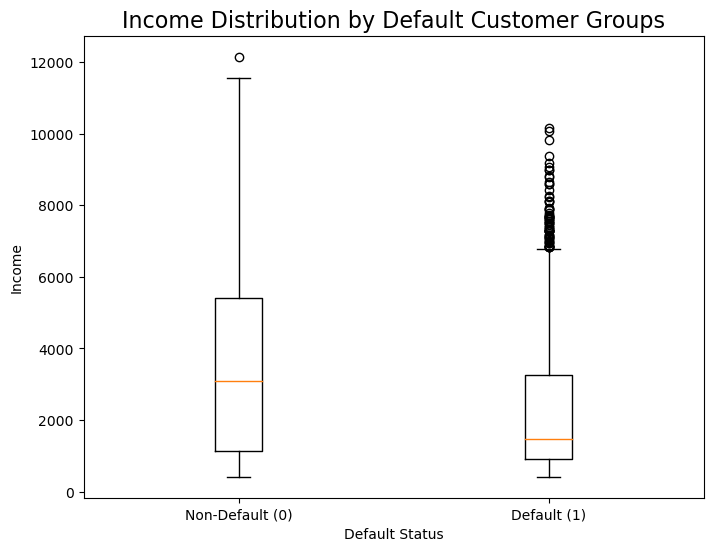

In [14]:
# Visualizing the income distribution of default and non-default customer of BNPL services
non_default = BNPL_Data[BNPL_Data['default_flag'] == 0]['monthly_income']
default = BNPL_Data[BNPL_Data['default_flag'] == 1]['monthly_income']

plt.figure(figsize=(8,6))

plt.boxplot(
    [non_default, default],
    labels=['Non-Default (0)', 'Default (1)'])

# Labels and title
# Default Status = 0 means does not default 
# Default Status = 1 means defaulted
plt.title('Income Distribution by Default Customer Groups', fontsize = 16)
plt.ylabel('Income')
plt.xlabel('Default Status')

# Show plot
plt.show()

**Based on the boxplot shows, we can see that the median monthly income of the customers that defaulted is slightly below 2000 and the median income of non-default customers is very close to 4000 per month. A lower median leading to higher chance of default is a rational and its observable that 75% of the customers thet defaults has monthly income lower than 4000**

### 1c Visualizing the debt to income ratio distribution using Histogram

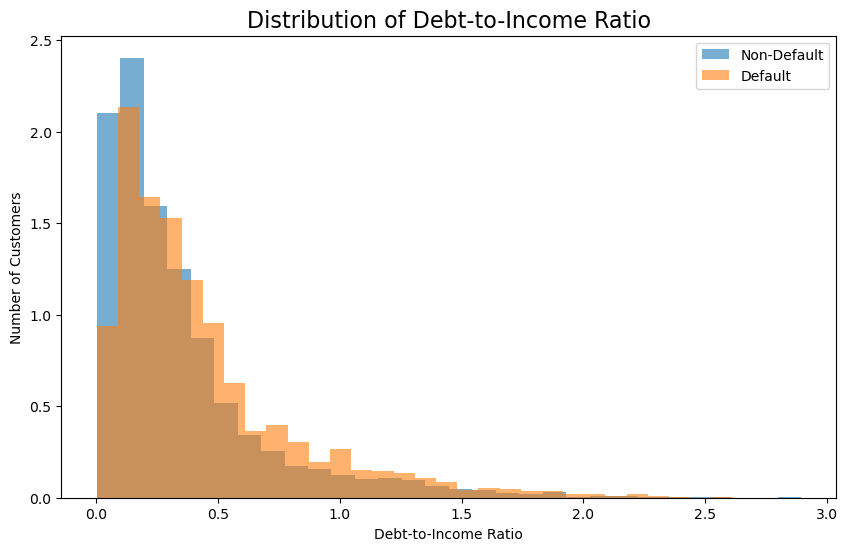

In [15]:
# Non-default customers
non_default = BNPL_Data[BNPL_Data['default_flag'] == 0]['debt_to_income_ratio']

# Default customers
default = BNPL_Data[BNPL_Data['default_flag'] == 1]['debt_to_income_ratio']

plt.figure(figsize=(10,6))

# histogram for non-defaulters
plt.hist(
    non_default,
    bins=30,
    alpha=0.6,
    density=True,
    label='Non-Default')

# histogram for defaulters
plt.hist(
    default,
    bins=30,
    alpha=0.6,
    density = True,
    label='Default')

plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Number of Customers')

plt.title('Distribution of Debt-to-Income Ratio', fontsize = 16)

plt.legend()

plt.show()

**The above histogram shows the distribution of debt to income ratio for the default and non-default groups, the histogram for both groups are right skewed with only a few people ar extremely high DTI values which make sense because people generally do not commit high amount of their income into BNPL repayments. However, there are still a small group of consumer that have debt to income ratio above 1 which shows some extreme case. Morever, we can see that the defaulters tends to be more concentrated at mid to higher DTI ranges which suggests that higher repayment burden may increase the chance of defaulting. Overall, even though high DTI ratio is associated with increased default risk, but the huge overlap shows that there may be other non-financial factors such as demographic and behavioral factors that contributes to defaulting in BNPL repayments.**

## Repayment Behaviour Analysis

### 1d Visualizing whether the higher missing payments is associated with default

In [16]:
# Creating a table that shows the proportion of people from each missed payment category that actually defaults
missed_payment_summary = (
    BNPL_Data.groupby('missed_payments')
      .agg(customers=('default_flag', 'count'),
          defaulters=('default_flag', 'sum'),
          default_rate=('default_flag', 'mean')).reset_index())

# Calculating the default rate for each missed_payments
missed_payment_summary['default_rate'] = (missed_payment_summary['default_rate'] * 100)

missed_payment_summary

,missed_payments,customers,defaulters,default_rate
0,0,3704,1027,27.726782
1,1,3837,1442,37.581444
2,2,1969,877,44.540376
3,3,653,538,82.388974
4,4,143,125,87.412587
5,5,31,23,74.193548
6,6,7,7,100.000000
7,7,1,1,100.000000


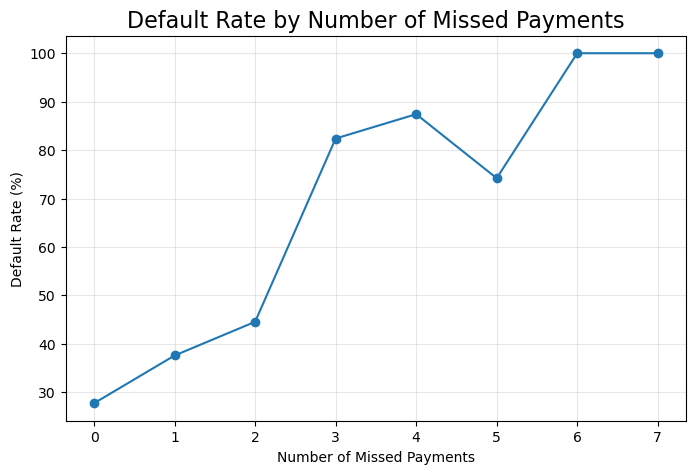

In [17]:
# Creating a line chart that shows changes of default rate as the number of missed payments increases.
plt.figure(figsize=(8,5))

# plotting the x and y axis of the line chart
plt.plot(missed_payment_summary['missed_payments'], 
         missed_payment_summary['default_rate'],
         marker='o')

# Labelling the Graphs
plt.title('Default Rate by Number of Missed Payments', fontsize = 16)
plt.xlabel('Number of Missed Payments')
plt.ylabel('Default Rate (%)')

plt.xticks(range(0, 8))

plt.grid(alpha=0.3)

plt.show()

**Overall, from the above line chart, we are able to notice a strong positive trend (positive correlation)
associated with missed payments and default rate, meaning as the number of missed payments increases, the default rate for the BNPL repayments are higher. Which make sense, because higher missed payments means the user may not have enough financial capabilities to pay off the repayments, which leads to defaulting.**

## Question 2 How do different customer groups use BNPL services?

**Overall, 3 areas will be explored to answer this question. By looking into the average purchase amounts and installment preferences accross different employment types and also looking into if app usage frequency influences defaults.**

**Overall, accross these 3 areas, all customer groups in terms of employment type have similar installment preferences and customer with more stable income source tends to have higher average purchase amounts using BNPL services compared to customer groups with less stable source of income. Adding on, default rates are similar accross users with different app usage frequencies, showing app usage is not a good indicator for customer defaults.**

### 2a Whats the average purchase amount by employment types?

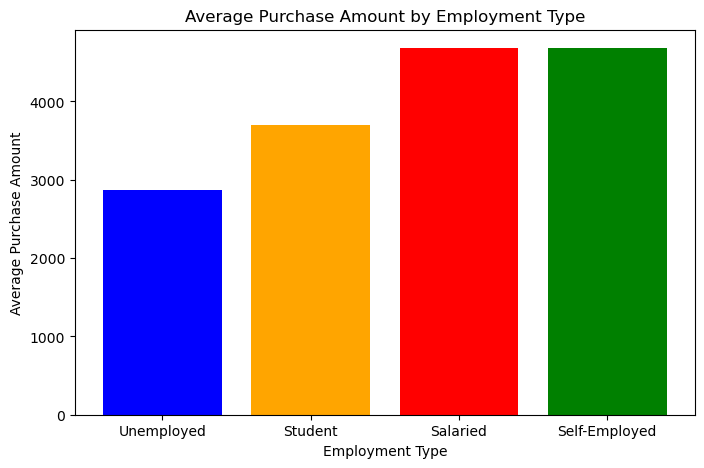

In [18]:
purchase_by_age = (
    BNPL_Data.groupby('employment_type', observed=False)['purchase_amount'].mean().reset_index())

purchase_by_age = purchase_by_age.sort_values(
    by='purchase_amount',
    ascending=True)

plt.figure(figsize=(8,5))

# Color coding each of the age group
colors = ["blue", "orange", "red", "green"]

# plotting the bar chart
plt.bar(
    purchase_by_age['employment_type'],
    purchase_by_age['purchase_amount'],
    color = colors)

plt.xlabel('Employment Type')
plt.ylabel('Average Purchase Amount')
plt.title('Average Purchase Amount by Employment Type')

plt.show()

**From the above bar chart, it can be observed Student and unemployed groups of customer (customer without stable income source) have a lower average purchase amount compared to the salaried and self-employed customer groups (customer groups with known income source). To some extent this may mean that people with less stable income source maybe more conservative in terms of the amount they would spend using BNPL services.**

### 2b whats the installment preferences accross age groups

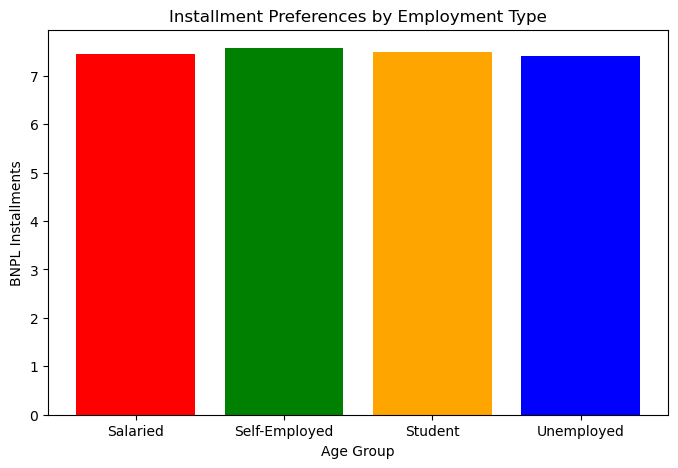

In [19]:
installment_by_age = (
    BNPL_Data.groupby('employment_type', observed=False)['bnpl_installments'].mean().reset_index())

plt.figure(figsize=(8,5))

# Color coding each of the age group
colors = ["r", "green", "orange", "blue", "yellow"]


plt.bar(
    installment_by_age['employment_type'],
    installment_by_age['bnpl_installments'],
    color = colors)

plt.xlabel('Age Group')
plt.ylabel('BNPL Installments')
plt.title('Installment Preferences by Employment Type')

plt.show()

**Based on the above bar chart, it can be observed that accross all customer groups in terms of employment type, all the customers have similar preferences in terms of BNPL installment options, on average they would pick a 7 installment plan (7 months, assuming 1 repayment each month).**

### 2c Does User with different Average App frequency usage per week shows different signs of default rates?

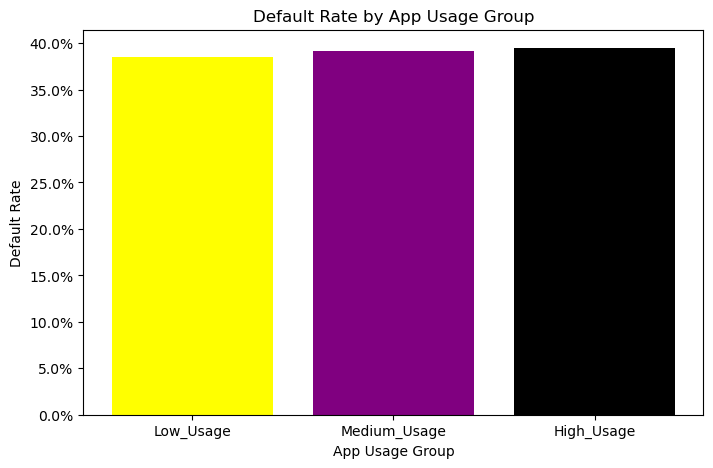

In [20]:
# Looking for relationship between App Usage Frequency and Default rate
# The current app_usage_frequency is assumed to be average app usage per week 
# Therefore will be using quantile binning to group different app usage frequency 
# Creating a new column called Usage Group (feature engineering)(33% in each usage group)
BNPL_Data['Usage_Group'] = pd.qcut(BNPL_Data['app_usage_frequency'], q=3, labels = ["Low_Usage", "Medium_Usage", "High_Usage"])


# Default Rate as per App Usage Groups 
app_usage_default_rate = BNPL_Data.groupby('Usage_Group', observed = False)['default_flag'].mean().reset_index()

# Creating a Bar Chart
plt.figure(figsize=(8,5))

colors = ['yellow', 'purple', 'black']

plt.bar(
    app_usage_default_rate['Usage_Group'],
    app_usage_default_rate['default_flag'],
    color = colors)

plt.ylabel('Default Rate')
plt.xlabel('App Usage Group')
plt.title('Default Rate by App Usage Group')

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1))

plt.show()

**The average BNPL app frequency usage per week is being categorized into 3 groups (Low, Medium and High), from the above bar chart, we can observe that there is more or less the same proportion of default rate across the 3 usage groups which is at around 38%. Therefore, the app usage frequency does not influence chances of default.** 

## Question 3 Which customer groups experience the greatest financial burden from BNPL usage

**For this question, 2 areas are explored, I look into the average DTI by employment types and the average installment amount by employment type. Overall, it can be observed customer with less stable income source (student and unemployed) customer groups tends to have a higher DTI ratio, meaning each installment amount covers a huge proportion of the potential income they earn. (Through government support or family), despite seeing that the average monthly installment for this group of customer is lower, It is still more important to see whether they have the ability to pay back the repayments. Therefore, unemployed and students have higher DTI ratio which is associated with greater financial burden.**

### 3a Average DTI by Employment Type

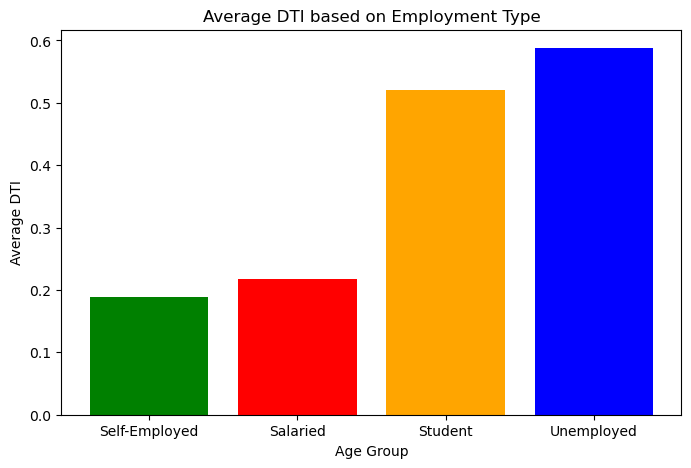

In [21]:

dti_by_employment = (
    BNPL_Data.groupby('employment_type', observed=False)['debt_to_income_ratio'].mean().reset_index())

# Sorting the values from the smallest to the largest
dti_by_employment = dti_by_employment.sort_values(
    by='debt_to_income_ratio',
    ascending=True)

plt.figure(figsize=(8,5))

# Color coding each of the age group
colors = ["green", "red", "orange", "blue"]


plt.bar(
   dti_by_employment['employment_type'],
    dti_by_employment['debt_to_income_ratio'],
    color = colors
)

plt.xlabel('Age Group')
plt.ylabel('Average DTI')
plt.title('Average DTI based on Employment Type')

plt.show()

**Based on the above bar chart, we can observe that customer groups that have a known source of income (Self-Employed and Salaried) have a much lower DTI meaning the BNPL repayments only consumes a smaller proportion of their income, thus representing less financial burden which potentially reduce risks of defaulting. However, customer groups (Student, Unemployed) with unknown Income source may face a larger financial burden which increases potential risks of default.**

### 3b Average Monthly Installment by Employment_Type

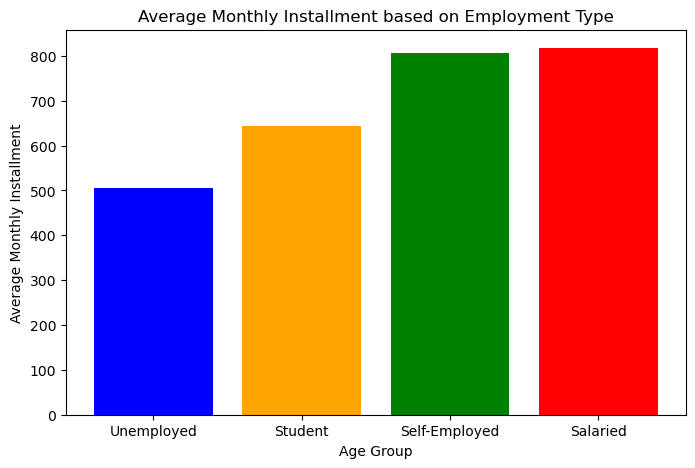

In [22]:
monthly_installment_by_employment = (
    BNPL_Data.groupby('employment_type', observed=False)['monthly_installment'].mean().reset_index())


# Sorting the values from the smallest to the largest
monthly_installment_by_employment  = monthly_installment_by_employment.sort_values(
    by='monthly_installment',
    ascending=True)

plt.figure(figsize=(8,5))

# Color coding each of the age group
colors = ["blue", "orange", "green", "red"]


plt.bar(
   monthly_installment_by_employment['employment_type'],
    monthly_installment_by_employment['monthly_installment'],
    color = colors
)

plt.xlabel('Age Group')
plt.ylabel('Average Monthly Installment')
plt.title('Average Monthly Installment based on Employment Type')

plt.show()

**From the above average monthly installment based on employment type, it can be seen that the average monthly installment is the highest for the group of customer with stable income source (Self-Employed and Salaried), this shows that the ability to repay the installment is a more crucial information than the amount that needs to be repaid.**

# 1.3 Feature engineering and supervised learning

## Learning Algorithm 1: KNN

**KNN is a supervised learning model that classifys an object based on the plurality vote of its neighbor, the object is being assigned to the class which is most common among the k valued neighbors.**

**Looking at the split of the data in terms of default and non default groups.**

In [23]:
# Checking the splits of the target variable in the whole dataset
BNPL_Data['default_flag'].value_counts()
BNPL_Data['default_flag'].value_counts(normalize=True)

0    0.609473
1    0.390527
Name: default_flag, dtype: float64

### Choosing the Target Variable and filtering out Feature selections

In [24]:
# Choosing the target variable (Y) and leaving the remaining variable as (X)
X = BNPL_Data.drop(columns = ['default_flag', 'user_id', 'product_category', 
                              'app_usage_frequency', 'location', 'transaction_date','Usage_Group', 'age_group'],axis=1)
y = BNPL_Data['default_flag']

### Preprocessing the Variables

**Using One-Hot encoding (Dummy variables), to ensure that the categorical variables can be used in modelling.**

In [25]:
# Using dummy variables for the categorical values because KNN cannot work with text data
X = pd.get_dummies(X, drop_first=True)
print(X)

       age  monthly_income  credit_score  purchase_amount  bnpl_installments  \
0       56     5710.791667           552          5000.00                 12   
1       19      603.987500           300          1073.23                 12   
2       20     3465.188333           471          5000.00                  3   
3       21     1201.955000           300          4076.83                  6   
4       43     3570.458333           512          5000.00                  9   
...    ...             ...           ...              ...                ...   
10340   52     1445.361667           393          5000.00                  6   
10341   53     1482.350000           300           100.00                 12   
10342   42     4945.854167           535          5000.00                 12   
10343   59     6144.978333           678          5000.00                  3   
10344   23      528.767500           360          1015.57                  9   

       repayment_delay_days  missed_pay

In [26]:
# Ensure that there are no string or object variables left in the data
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            10345 non-null  int64  
 1   monthly_income                 10345 non-null  float64
 2   credit_score                   10345 non-null  int64  
 3   purchase_amount                10345 non-null  float64
 4   bnpl_installments              10345 non-null  int64  
 5   repayment_delay_days           10345 non-null  int64  
 6   missed_payments                10345 non-null  int64  
 7   debt_to_income_ratio           10345 non-null  float64
 8   risk_score                     10345 non-null  float64
 9   monthly_installment            10345 non-null  float64
 10  employment_type_Self-Employed  10345 non-null  uint8  
 11  employment_type_Student        10345 non-null  uint8  
 12  employment_type_Unemployed     10345 non-null 

### Training and Test Split

**Created an 80:20 training test split, and used a random state value 42 to ensure that the code is reproducible.**

In [27]:
# splitting the data with 80% Training and 20% Test Ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

### Feature Scaling

**KNN model uses distance calculations and therefore without appropriate scaling would lead to certain variables like income to dominate over oother variables because of its huge value.**

In [28]:
# Scaling the datas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Buidling the KNN Model with 5 fold cross validation based hyperparameter tuning (value of k) and making predictions

**The following is to measure the performance of a 5 fold cross validation KNN Model with values of k ranging from 1 to 23, and identifying the value of k that yields the highest accuracy value based on the training data.**

In [29]:
# Building the knn Model
# Creating a range of k values that will be used for training
neighbours = list(range(1,25,2))

# Storing various metrics for model performance
accuracy_scores = []
f1_scores = []

# Training model to see which value of k yields the best performance based on the metrics. 
for k in neighbours:
    knn = KNeighborsClassifier(n_neighbors=k)
    # accuracy metric
    accuracy_scores.append(cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring = 'accuracy').mean())
    # f1 metric
    f1_scores.append(cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring = 'f1').mean())

**The following table shows that as the value of k increases, there is a slight increase in the accuracy of the model but the F1 score have a slight decrease .** 

In [30]:
results = pd.DataFrame({
    'k': neighbours,
    'Accuracy': accuracy_scores,
    'F1 Score': f1_scores})

print(results)

     k  Accuracy  F1 Score
0    1  0.636177  0.531945
1    3  0.648623  0.535709
2    5  0.657564  0.538917
3    7  0.665057  0.539372
4    9  0.666144  0.531037
5   11  0.670615  0.533678
6   13  0.668076  0.527722
7   15  0.672789  0.530392
8   17  0.676051  0.531618
9   19  0.674360  0.525816
10  21  0.673756  0.525600
11  23  0.677139  0.525601


**The following shows a graph that shows the accuracy of the of the 5 fold CV knn model at different values of k. As shown on the graph, the accuracy (line in orange) of the model peaks when k is 23. However, the F1 score (line in blue) is the highest when k = 7 and an increment in k leads to an overall drop of the f1 score. In the context of a BNPL provider, it is more important to know which customer defaults than not default, the accuracy metric only looks at the performance in classifying the customer into the correct group (default or non-default) whereas the f1 score actually looks into the performance in identifying customers that defaults. Even though with k = 7, the f1 score being at 0.54 shows average model performance, And also since the accuracy metrics only show slight improvements as the value of k increase. The best value of k would be 7.**

### KNN Hyperparameter Tuning (5-Fold CV) F1 Score and Accuracy

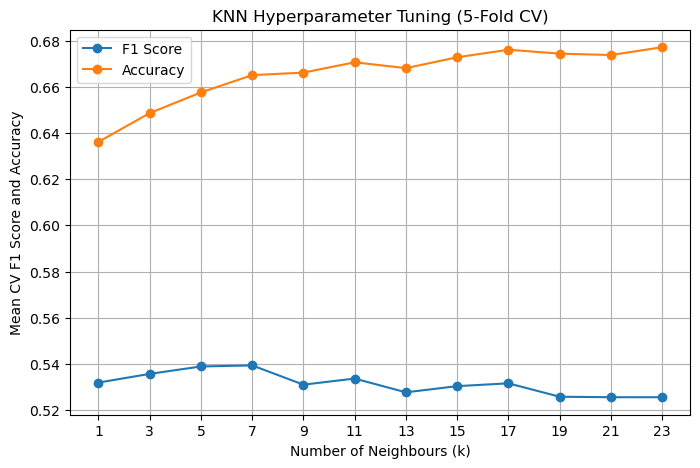

In [31]:
plt.figure(figsize=(8,5))

# plotting the line based on the metric performance and the corresponding k values
plt.plot(neighbours, f1_scores, marker='o', label = "F1 Score")
plt.plot(neighbours, accuracy_scores, marker='o', label = "Accuracy")

# Labelling the graph
plt.xlabel('Number of Neighbours (k)')
plt.ylabel('Mean CV F1 Score and Accuracy')
plt.title('KNN Hyperparameter Tuning (5-Fold CV)')

plt.xticks(neighbours)

plt.grid(True)

plt.legend()

plt.show()

**The following shows k = 7 yields the highest f1 score**

In [32]:
# identifying the best value of k and the f1 score of the best value.
best_k_val = neighbours[f1_scores.index(max(f1_scores))]
print(f"Best k: {best_k_val}")
print(f"Best mean CV f1 score: {max(f1_scores):.4f}")

Best k: 7
Best mean CV f1 score: 0.5394


### Initializing the KNN Model and Making Predictions

Accuracy: 0.6796
Precision: 0.6068
Recall: 0.5099
f1 Score: 0.5541


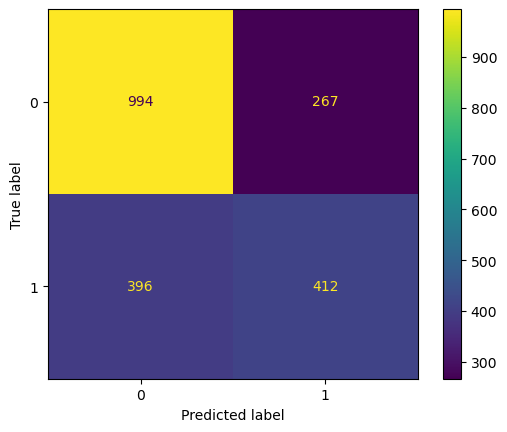

In [33]:
# Setting up the knn model
knn = KNeighborsClassifier(n_neighbors = best_k_val)

# Fitting the model with the best k value
knn.fit(X_train_scaled, y_train)

# knn model prediction
y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"f1 Score: {f1:.4f}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

**Based on the performance metrics (accuracy, Precision, Recall and f1 score), overall we can see that knn model is just performing average in classifying customers into default and non-default groups. Based on the confusion matrix values the True negatives (994) meaning these are customers that did not default and the model were able to correctly predict it as non-default is greater than 412 (True Positives, customers who actually defaulted and were correctly predicted as default), this means that the knn model is considerably more effective at identifying customers who will not default than the customers who will default.**

**Overall, based on the confusion matrix above, 994 out of 1261 (994 + 267) non default customers were correctly identified and 412 out 808 (412 + 396) default customers were correctly identified which suggests that the model is more effective in identifying non defaulters and therefore there should be room for improvements in detecting risky borrowers. This limitation is important because as a BNPL Provider, undetected defaulters may contribute to financial losses.**

## Learning Algorithm 2: Decision Trees

**A decision tree is a tree structured model for supervised learning that predicts the target variable by learning decision rules and a decision tree would have multiple decision rules.**

**Note: Decision tree is able to work with continuous and categorical variable and needs minimal data preprocessing, therefore dummy variables does not be created. Moreover, since decision tree does not calculate distance, its based on splitting the data on a specific threshold. Therefore, the data does not need to be scaled.**

### Buidling the Decision Tree Model with 5 fold cross validation based hyperparameter tuning (value of depth) and making predictions

**The following is to measure the performance of a 5 fold cross validation Decision Tree Model with values of depth ranging from 1 to 23, and identifying the value of depth that yields the highest accuracy value based on the training data.**

In [34]:
depths = range(1, 21)

accuracy_scores = []
f1_scores = []
# looping through all the depths within the range and recording thier accuracy and f1 score
for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42)
    # accuracy metric
    accuracy_scores.append(cross_val_score(tree,X_train,y_train,cv=5,scoring='accuracy').mean())
    # f1 metric
    f1_scores.append(cross_val_score(tree,X_train,y_train,cv=5,scoring='f1').mean())

**Based on the Decision Tree Hyperparameter performance metrics graph below, we can see that the accuracy metric is higher than the f1 score metrics and all values of depth, and the overall performance of each value depth seems quite constant (little variation) when depth value is greater than 2.5. This shows that after a few splits of decisions, the model more or less would give the same result in classifying a customer into default and non-default groups.**

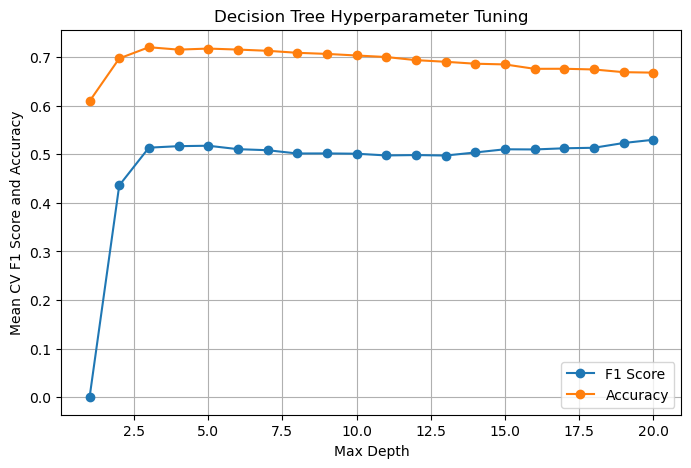

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

#Plotting the lines 
plt.plot(depths, f1_scores, marker='o', label = "F1 Score")
plt.plot(depths, accuracy_scores, marker='o', label = "Accuracy")

# labels of the graph
plt.xlabel('Max Depth')
plt.ylabel('Mean CV F1 Score and Accuracy')
plt.title('Decision Tree Hyperparameter Tuning')

plt.legend()

plt.grid(True)

plt.show()

**Based on the mean cv f1 score, the best depth value is 20. The f1 score is used to determine the value of depth is because from a BNPL providers perspective, it is more important to identify the defaulters correctly as this helps the BNPL provider better manage and understand their risks and financial losses.**

In [36]:
best_depth = depths[f1_scores.index(max(f1_scores))]

# identifying the best depth (hyperparameter and its f1 score)
print(f"Best Depth: {best_depth}")
print(f"Best mean CV f1 score: {max(f1_scores):.4f}")

Best Depth: 20
Best mean CV f1 score: 0.5300


### Initializing the Decision Tree Model and Making Predictions

Accuracy: 0.6646
Precision: 0.5758
Recall: 0.5359
f1 Score: 0.5551


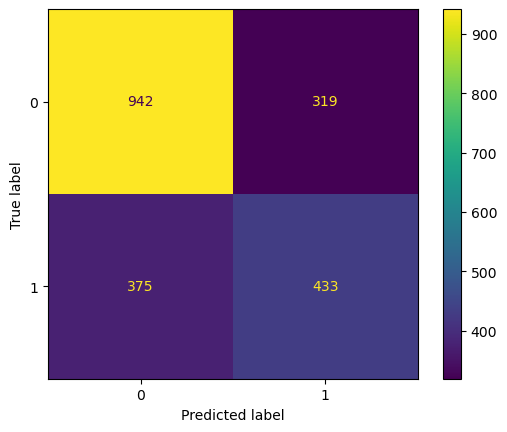

In [37]:
#Initializing the model
tree = DecisionTreeClassifier(max_depth=best_depth,random_state=42)

# fitting the model
tree.fit(X_train, y_train)

# Model Prediction
y_pred_tree = tree.predict(X_test)

# Model Performance metrics
accuracy = accuracy_score(y_test, y_pred_tree)
precision = precision_score(y_test, y_pred_tree)
recall = recall_score(y_test, y_pred_tree)
f1 = f1_score(y_test, y_pred_tree)


print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"f1 Score: {f1:.4f}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)

**Based on the performance metrics (accuracy, Precision, Recall and f1 score), overall we can see that decision tree model is just performing average in classifying customers into default and non-default groups. Based on the confusion matrix values the True negatives (942) meaning these are customers that did not default and the model were able to correctly predict it as non-default is greater than 433 (True Positives, customers who actually defaulted and were correctly predicted as default), this means that the decision tree model is also considerably more effective at identifying customers who will not default than the customers who will default.**

**Overall based on the confusion matrix above 942 out of 1261 (942 + 319) non default customers were correctly identified and 433 out of 808 (433 + 375) default customers were correctly identified which suggests that the model is more effective in identifying non defaulters and therefore there should be room for improvements in detecting risky borrowers. This limitation is important because as a BNPL Provider, undetected defaulters may contribute to financial losses.**

### Feature Importance Table (decision tree model)

In [38]:
# Feature importance table based on the decision tree model
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tree.feature_importances_})
# Sorting the feature importance from most important to least important
feature_importance = feature_importance.sort_values(
    by='Importance', ascending=False)

feature_importance


,Feature,Importance
2,credit_score,0.276536
5,repayment_delay_days,0.178960
1,monthly_income,0.103996
8,risk_score,0.098436
7,debt_to_income_ratio,0.093593
0,age,0.088576
6,missed_payments,0.050721
9,monthly_installment,0.039114
3,purchase_amount,0.039092
11,employment_type_Student,0.009191


**The above is feature importance table that is generated through the decision tree model, based on the results, it can be observed that credit_score is an important indicator of whether a customer would default, which make sense because as a higher credit score means this individual have good credit record which may reduce the chances of defaulting and vice versa. And the next significant indicators includes repayment_delay_days and monthly_income which make sense because it is associated with the repayment behaviours and the financial ability to repay the BNPL installments.**

### Comparing the Model Performance (KNN V Decision Trees)

In [39]:
# Setting up the model performance comparison table
model_comparison_table = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree'],
    'Best Hyperparameter': ['k=7', 'max_depth=20'],
    'Accuracy': [0.679, 0.665],
    'Precision': [0.606, 0.5760],
    'Recall': [0.509, 0.536],
    'F1 Score': [0.554, 0.555]})
# make the model performance comparison table look nicer
model_comparison_table.style.format({
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1 Score': '{:.2%}'})

,Model,Best Hyperparameter,Accuracy,Precision,Recall,F1 Score
0,KNN,k=7,67.90%,60.60%,50.90%,55.40%
1,Decision Tree,max_depth=20,66.50%,57.60%,53.60%,55.50%


**Based on the model performance comparison table, both KNN and Decision tree has very similar performance having an f1 score of 55.40% and 55.5%, which is almost identical,which means they would yield a very similar result in classifying customers into default and non-default groups. While the KNN performed better in the Precision scores and the accuracy, the decision tree performs better in the Recall scores and F1 scores. Overall, even though both model shows very similar performance, but the decision tree model did give additional insights to feature strenghts (feature importance table) that contributes to identifying default and non-default customer. The decision tree would be better for this dataset.**

**However, it is important to note that since only 2 models were being used and since the model performance is not the best, it would be a wise choice to explore other models or obtain data with features that gives stronger contribution in helping identifying defaults in customers. As the performance of the model is heavily reliant on the quality of data being used.**